# Quantum Gibbs sampler — run notebook

This notebook only *runs* the code. All function and class definitions live in `definitions.py` (same folder) and are imported below.

- Three Lindbladian constructions: time domain, frequency domain, and Anthony's construction.
- Sanity checks that all three constructions agree.
- A convergence-time sweep over `sigma` and `beta`, with comparison plots.

## Imports

Pull in everything from `definitions.py`.

In [1]:
from __future__ import annotations
import sys
import time
import itertools
import random
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh, expm

sys.path.append('..')
from gibbs_state_prep.helpers import ising_1d, heisenberg_1d, compute_trace_distance, I, X, Y, Z, kron, kron_n, compute_fidelity
from gibbs_state_prep.algorithm.preparation import IntegrationGrid
from gibbs_state_prep.exact.gibbs_state import GibbsState

from ROBERTS_sampler.definitions import *

# Parameters

In [2]:
number_of_spins = 3
J = 1
h = 0.8

## Build the local Z jump operators

In [3]:
coupling_ops = normalized_simple_jumps(number_of_spins)

## Sanity check: fast linear-algebra helpers

Checks the vectorized NumPy replacements for the old qutip operations against brute-force reference implementations on random operators.

In [4]:
validate_fast_linear_algebra()

All fast linear-algebra identities match their reference implementations.


## Check that all Lindbladian constructions satisfy DB and trace 0

Build the Hamiltonian, pick a random $\sigma$ and $\beta$, construct the Lindbladian with all three methods, and compare the $L^\dagger(I)=0$ / detailed-balance residuals plus the pairwise differences between constructions.

In [5]:
hamiltonian = ising_1d(n=number_of_spins, J= J ,h= h, periodic=True )

sigma_value = random.uniform(0,2)
beta_value = random.uniform(0,2)
S_value = 10

int_grid = IntegrationGrid(10,10201)

print("The random sigma is = ", sigma_value)
print("The random beta is = ", beta_value)
print('')

eig_cache_single: Dict = {}
lindbladians = {}
gibbs_states = {}
d = hamiltonian.shape[0]

for name, builder in LINDBLADIANS.items():
    if name == "BA":
        continue
    Lind, rho_g = builder(hamiltonian, beta_value, sigma_value, S_value, int_grid, coupling_ops,
                           q_filter="gaussian", eig_cache=eig_cache_single)
    lindbladians[name] = Lind
    gibbs_states[name] = rho_g
    print(f"[{name}]")
    print(f"  max|L^dagger(I)|          = {l_dagger_identity_residual(Lind, d):.3e}")
    print(f"  detailed-balance residual = {detailed_balance_residual(Lind, rho_g):.3e}")

print('')
BA_builder = LINDBLADIANS["BA"]

for ba_gamma_filter in GAMMAS_BA:
    try:
        Lind_BA, rho_g_BA = BA_builder(hamiltonian, beta_value, sigma_value, S_value, int_grid, coupling_ops,
                                        q_filter=ba_gamma_filter, eig_cache=eig_cache_single)
    except ValueError:
        print(f"[L_BA, transition rate gamma(w): {ba_gamma_filter}]  skipped: sigma_value={sigma_value:.3g} is out of the "
              f"valid range for this rate at beta_value={beta_value:.3g}")
        continue
    print(f"[L_BA, ransition rate gamma(w): {ba_gamma_filter}]")
    print(f"  max|L^dagger(I)|          = {l_dagger_identity_residual(Lind_BA, d):.3e}")
    print(f"  detailed-balance residual = {detailed_balance_residual(Lind_BA, rho_g_BA):.3e}")


The random sigma is =  0.9838291998832778
The random beta is =  1.8603009873398666



/Users/lorisweber/Desktop/Roberts_Gibbs_sampler/ROBERTS_sampler/../ROBERTS_sampler/definitions.py:408: RuntimeWarning: overflow encountered in exp
  return np.exp(-nu**2 / (8 * sigma**2)) / (1 + np.exp(beta * nu / 2))


[L_R_time_domain]
  max|L^dagger(I)|          = 2.442e-14
  detailed-balance residual = 1.498e-11
[L_R_frequency_domain]
  max|L^dagger(I)|          = 4.649e-16
  detailed-balance residual = 1.043e-12
[L_R_anthony_time_construction]
  max|L^dagger(I)|          = 4.419e-14
  detailed-balance residual = 1.498e-11
[L_R_anthony_frequency_construction]
  max|L^dagger(I)|          = 4.626e-14
  detailed-balance residual = 1.043e-12

[L_BA, ransition rate gamma(w): metropolis]
  max|L^dagger(I)|          = 9.610e-16
  detailed-balance residual = 1.738e-05
[L_BA, transition rate gamma(w): gaussian]  skipped: sigma_value=0.984 is out of the valid range for this rate at beta_value=1.86


## Convergence-time sweep for Roberts Lindbladian L_R with frequency domain constr. and Anthony frequency domain constr.

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [6]:
#sigma_values = np.linspace(0.2,2.2,10)
sigma_values =  np.linspace(0.1, 4, 10)  
beta_values = np.linspace(0.2, 1.2, 4)

#beta_values = np.linspace(1e-3,5e-2,6)

q_filter_ = 'metropolis'
threshold_value = 1e-3
max_evo_time = 1e12
method_for_evo = 'SPECTRAL' #RK4 much slower then 'SPECTRAL'

results_df = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_beta_dependency, S_value, coupling_ops,
    constructions= ('L_R_frequency_domain',),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df

[1/40] L_R_frequency_domain sigma=0.1 beta=0.2 -> t_conv=37.223  L+_res=6.07e-16  DB_res=1.50e-13  spectral_gap 0.132909
[2/40] L_R_frequency_domain sigma=0.1 beta=0.5333 -> t_conv=39.6383  L+_res=2.32e-16  DB_res=5.14e-13  spectral_gap 0.139872
[3/40] L_R_frequency_domain sigma=0.1 beta=0.8667 -> t_conv=40.0761  L+_res=3.68e-16  DB_res=8.75e-13  spectral_gap 0.145405
[4/40] L_R_frequency_domain sigma=0.1 beta=1.2 -> t_conv=39.8933  L+_res=3.89e-16  DB_res=1.10e-12  spectral_gap 0.149124
[5/40] L_R_frequency_domain sigma=0.5333 beta=0.2 -> t_conv=37.2232  L+_res=7.36e-16  DB_res=1.75e-13  spectral_gap 0.132909
[6/40] L_R_frequency_domain sigma=0.5333 beta=0.5333 -> t_conv=39.6384  L+_res=4.09e-16  DB_res=5.63e-13  spectral_gap 0.139871
[7/40] L_R_frequency_domain sigma=0.5333 beta=0.8667 -> t_conv=40.0762  L+_res=6.11e-16  DB_res=9.13e-13  spectral_gap 0.145404
[8/40] L_R_frequency_domain sigma=0.5333 beta=1.2 -> t_conv=39.8934  L+_res=5.60e-16  DB_res=1.12e-12  spectral_gap 0.149123
[

,construction,sigma,beta,convergence_time,wall_time_sec,converged,l_dagger_id_residual,detailed_balance_residual,valid_generator,spectral_gap,rho_converged
0,L_R_frequency_domain,0.100000,0.200000,37.223040,0.174124,True,6.071532e-16,1.498590e-13,True,0.132909,"[[(0.06643203112109837+0j), (-0.01578326614188..."
1,L_R_frequency_domain,0.100000,0.533333,39.638286,0.097203,True,2.324529e-16,5.136873e-13,True,0.139872,"[[(0.026351531238149716+0j), (-0.0286302873987..."
2,L_R_frequency_domain,0.100000,0.866667,40.076103,0.080474,True,3.677614e-16,8.753822e-13,True,0.145405,"[[(0.018274333068305035+0j), (-0.0354543856603..."
3,L_R_frequency_domain,0.100000,1.200000,39.893313,0.079921,True,3.885781e-16,1.103409e-12,True,0.149124,"[[(0.018134775938840685+0j), (-0.0412923350147..."
4,L_R_frequency_domain,0.533333,0.200000,37.223223,0.062237,True,7.355228e-16,1.754077e-13,True,0.132909,[[(0.06643231302114568-6.999157721688039e-22j)...
5,L_R_frequency_domain,0.533333,0.533333,39.638433,0.063045,True,4.093947e-16,5.633572e-13,True,0.139871,"[[(0.026351835795337567+0j), (-0.0286304438752..."
6,L_R_frequency_domain,0.533333,0.866667,40.076214,0.062026,True,6.106227e-16,9.128998e-13,True,0.145404,"[[(0.018274610965897095+0j), (-0.0354545299796..."
7,L_R_frequency_domain,0.533333,1.200000,39.893387,0.062223,True,5.603157e-16,1.115329e-12,True,0.149123,"[[(0.018135038565948575+0j), (-0.0412924731029..."
8,L_R_frequency_domain,0.966667,0.200000,37.936729,0.064767,True,4.492934e-16,1.938508e-13,True,0.130356,"[[(0.06645018618402512+0j), (-0.01579558553036..."
9,L_R_frequency_domain,0.966667,0.533333,40.209275,0.061504,True,7.840950e-16,5.932214e-13,True,0.125656,[[(0.02637704681201119+9.768688234983875e-33j)...


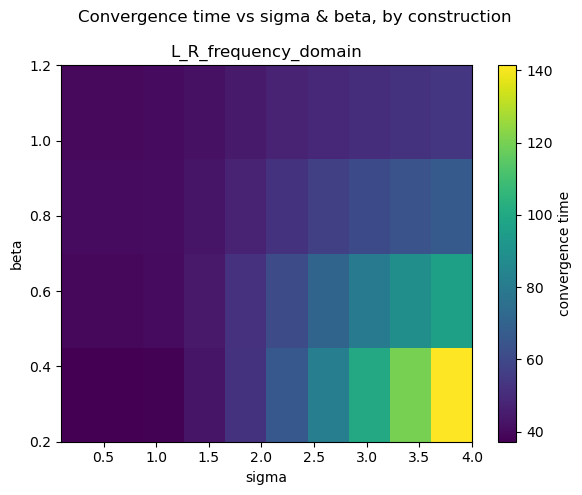

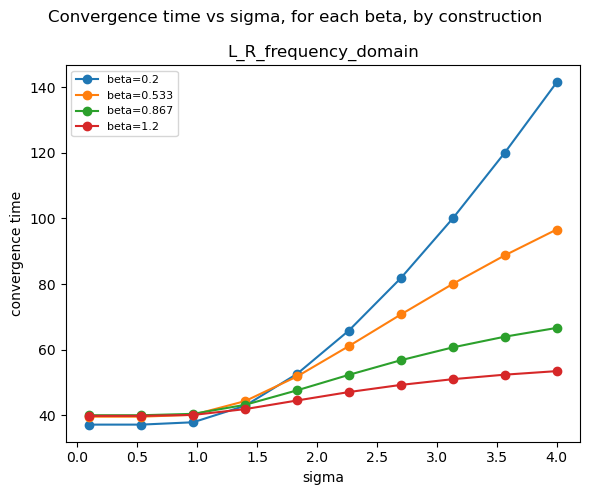

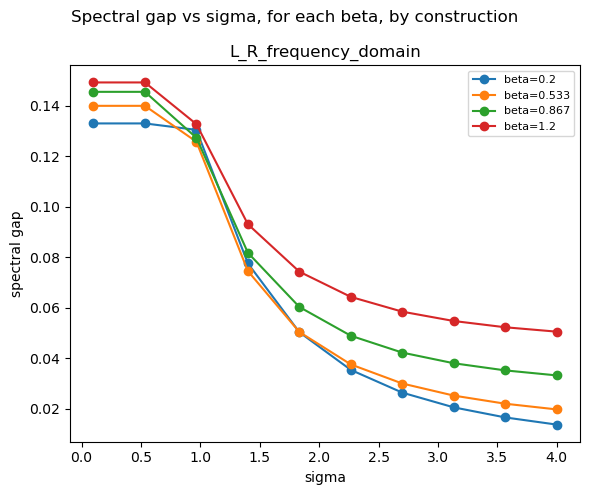

In [7]:
plot_convergence_heatmap(results_df, False)
plot_convergence_lines(results_df,'linear')
plot_spectral_gap_lines(results_df,'linear') 

# Fidelity of rho_converged and ground state

In [8]:
evals, evecs = get_eig(hamiltonian=hamiltonian, eig_cache= eig_cache_single)
idx = np.argmin(evals)
psi0 = evecs[:, idx]
psi0 = psi0 / np.linalg.norm(psi0)
ground_state = np.outer(psi0, psi0.conj())

high_beta = [1]
results_for_high_beta = run_convergence_sweep(
    hamiltonian, sigma_values, high_beta, grid_with_beta_dependency, S_value, coupling_ops,
    constructions= ( "L_R_frequency_domain", ),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

row = results_for_high_beta.loc[
    (results_for_high_beta["construction"] == "L_R_frequency_domain")
    & (results_for_high_beta["sigma"] == sigma_values[2])
    & (results_for_high_beta["beta"] == high_beta[0])
].iloc[0]

rho_converged = row["rho_converged"]
rho_converged


fidelity = compute_fidelity(ground_state, rho_converged)
fidelity

[1/10] L_R_frequency_domain sigma=0.1 beta=1 -> t_conv=40.0264  L+_res=2.29e-16  DB_res=9.86e-13  spectral_gap 0.147119
[2/10] L_R_frequency_domain sigma=0.5333 beta=1 -> t_conv=40.0265  L+_res=4.89e-16  DB_res=1.01e-12  spectral_gap 0.147119
[3/10] L_R_frequency_domain sigma=0.9667 beta=1 -> t_conv=40.39  L+_res=7.65e-16  DB_res=1.03e-12  spectral_gap 0.129120
[4/10] L_R_frequency_domain sigma=1.4 beta=1 -> t_conv=42.7015  L+_res=6.51e-16  DB_res=1.03e-12  spectral_gap 0.085987
[5/10] L_R_frequency_domain sigma=1.833 beta=1 -> t_conv=46.2947  L+_res=6.07e-16  DB_res=1.03e-12  spectral_gap 0.065605
[6/10] L_R_frequency_domain sigma=2.267 beta=1 -> t_conv=49.981  L+_res=1.48e-15  DB_res=1.03e-12  spectral_gap 0.054787
[7/10] L_R_frequency_domain sigma=2.7 beta=1 -> t_conv=53.2406  L+_res=5.39e-16  DB_res=1.03e-12  spectral_gap 0.048448
[8/10] L_R_frequency_domain sigma=3.133 beta=1 -> t_conv=55.9522  L+_res=4.20e-16  DB_res=1.03e-12  spectral_gap 0.044443
[9/10] L_R_frequency_domain sig

0.5428470531185702

## Convergence time and spectral gap multiplied with a HASTLE function

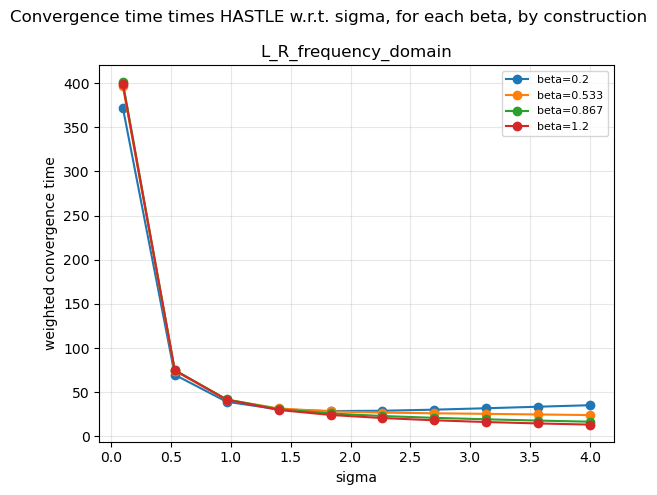

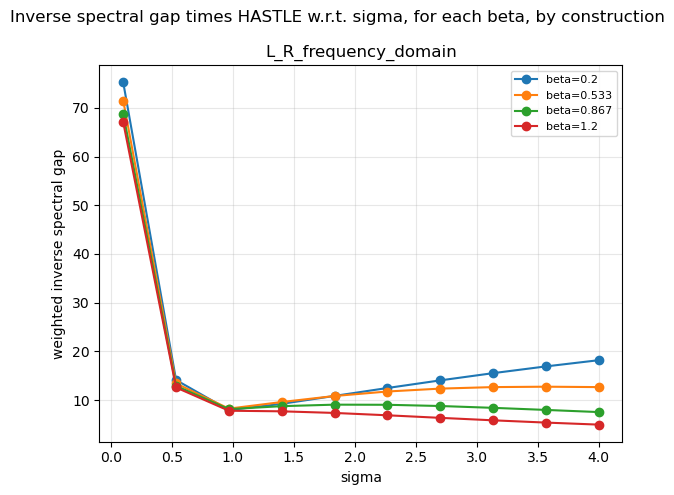

{'L_R_frequency_domain': beta       0.200000   0.533333   0.866667   1.200000
 sigma                                               
 0.100000  75.239172  71.494023  68.773619  67.058451
 0.533333  14.107415  13.405187  12.895094  12.573485
 0.966667   7.935799   8.232641   8.131215   7.800661
 1.400000   9.214348   9.587864   8.739288   7.678742
 1.833333  10.845404  10.826360   9.048466   7.346315
 2.266667  12.468779  11.750045   9.021898   6.863829
 2.700000  14.034442  12.344266   8.769560   6.338660
 3.133333  15.517951  12.653166   8.394215   5.830746
 3.566667  16.903323  12.736807   7.965794   5.364989
 4.000000  18.179689  12.653316   7.526152   4.948178}

In [9]:
'''
Choices for the HASTLE function:    "inverse_sigma", "inverse_sigma_beta", "inverse_sigma_sq", "inverse_sigma_beta_sq", "constant"
'''

hastle_name = "inverse_sigma"  

plot_convergence_time_times_hastle(results_df, 'L_R_frequency_domain',HASTLE_FUNCTIONS[hastle_name],'convergence_time' )
plot_convergence_time_times_hastle(results_df, 'L_R_frequency_domain',HASTLE_FUNCTIONS[hastle_name],'inverse_gap' )



# Lets compare both Lindbladians

In [10]:
filter_BA = 'metropolis'


results_BA = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_beta_dependency, S_value, coupling_ops,
    constructions= ( "BA",),
    q_filter=filter_BA, threshold= 1e-2, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_BA["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_BA)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_BA.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_BA

[1/40] BA                sigma=0.1 beta=0.2 -> t_conv=15.3857  L+_res=9.31e-15  DB_res=1.14e-08  spectral_gap 0.171770
[2/40] BA                sigma=0.1 beta=0.5333 -> t_conv=20.1623  L+_res=7.55e-15  DB_res=5.09e-08  spectral_gap 0.158533
[3/40] BA                sigma=0.1 beta=0.8667 -> t_conv=22.035  L+_res=4.22e-15  DB_res=6.49e-08  spectral_gap 0.157564
[4/40] BA                sigma=0.1 beta=1.2 -> t_conv=22.7326  L+_res=4.22e-15  DB_res=2.97e-08  spectral_gap 0.158145
[5/40] BA                sigma=0.5333 beta=0.2 -> t_conv=15.3888  L+_res=1.33e-14  DB_res=2.76e-09  spectral_gap 0.171734
[6/40] BA                sigma=0.5333 beta=0.5333 -> t_conv=20.194  L+_res=5.29e-15  DB_res=4.73e-09  spectral_gap 0.158472
[7/40] BA                sigma=0.5333 beta=0.8667 -> t_conv=22.0833  L+_res=5.36e-15  DB_res=1.07e-08  spectral_gap 0.157509
[8/40] BA                sigma=0.5333 beta=1.2 -> t_conv=22.813  L+_res=6.33e-15  DB_res=1.23e-09  spectral_gap 0.158110
[9/40] BA                si

,construction,sigma,beta,convergence_time,wall_time_sec,converged,l_dagger_id_residual,detailed_balance_residual,valid_generator,spectral_gap,rho_converged
0,BA,0.100000,0.200000,15.385662,0.171861,True,9.311996e-15,1.141292e-08,True,0.171770,"[[(0.07032421023350888+0j), (-0.01477807845440..."
1,BA,0.100000,0.533333,20.162332,0.160023,True,7.549517e-15,5.092651e-08,True,0.158533,"[[(0.030089280753378515+0j), (-0.0276424444086..."
2,BA,0.100000,0.866667,22.035004,0.179088,True,4.218847e-15,6.494969e-08,True,0.157564,"[[(0.021328385389449752+0j), (-0.0345828951914..."
3,BA,0.100000,1.200000,22.732594,0.224742,True,4.218847e-15,2.966366e-08,True,0.158145,"[[(0.020840032045685002+0j), (-0.0404330596716..."
4,BA,0.533333,0.200000,15.388803,0.152971,True,1.329492e-14,2.755783e-09,True,0.171734,"[[(0.0703276661799186-3.866189781914074e-23j),..."
5,BA,0.533333,0.533333,20.193955,0.156481,True,5.285702e-15,4.732564e-09,True,0.158472,"[[(0.030079723735063967+0j), (-0.0276517232673..."
6,BA,0.533333,0.866667,22.083281,0.162469,True,5.356826e-15,1.067876e-08,True,0.157509,"[[(0.021315456106019034+0j), (-0.0345967028405..."
7,BA,0.533333,1.200000,22.813036,0.187297,True,6.328271e-15,1.231668e-09,True,0.158110,"[[(0.02081623702169209+0j), (-0.04045425216169..."
8,BA,0.966667,0.200000,15.714835,0.150521,True,1.560557e-14,5.496627e-10,True,0.168045,"[[(0.07050062085685029+0j), (-0.01489703324555..."
9,BA,0.966667,0.533333,20.653287,0.155055,True,3.859760e-15,4.145437e-09,True,0.142792,"[[(0.03029248568850562+0j), (-0.02781063423532..."


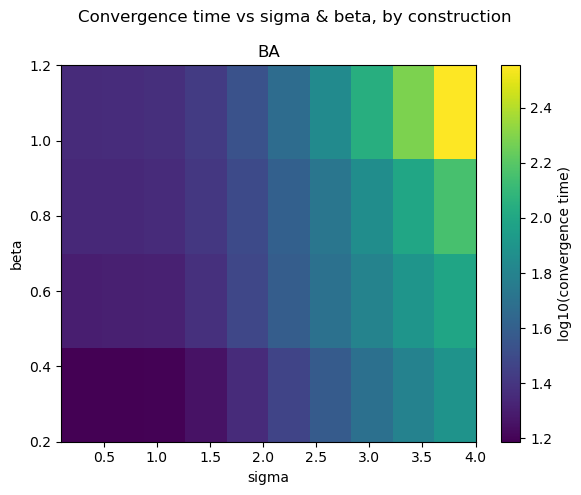

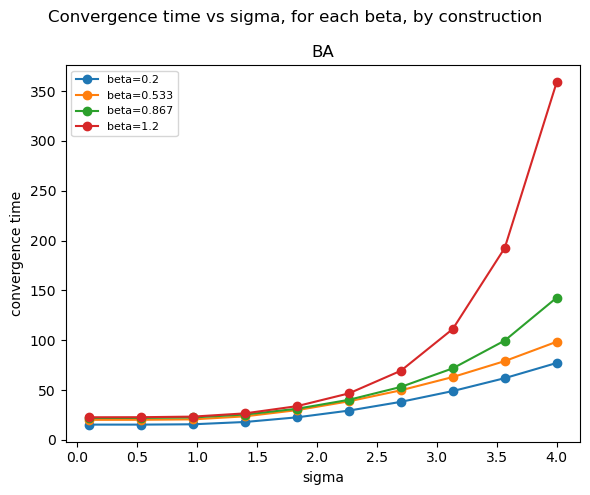

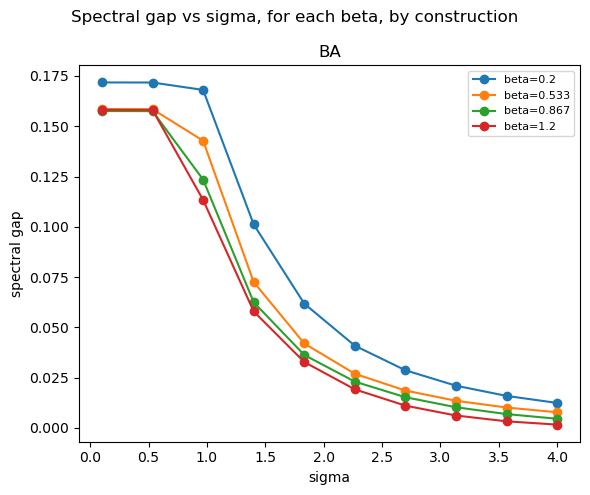

In [11]:
plot_convergence_heatmap(results_BA)
plot_convergence_lines(results_BA,'linear')
plot_spectral_gap_lines(results_BA, 'linear')

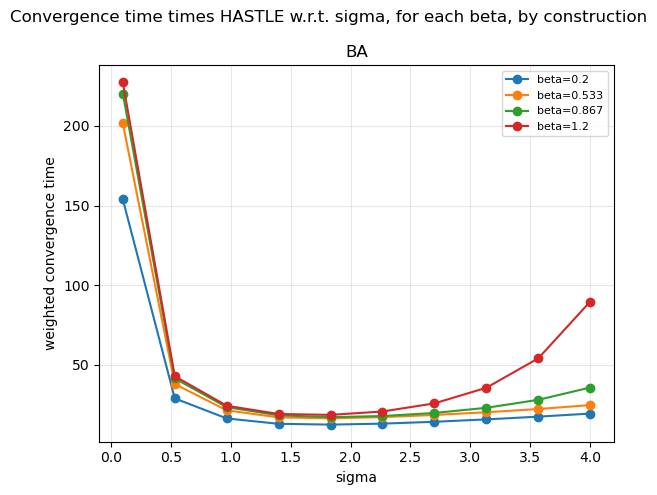

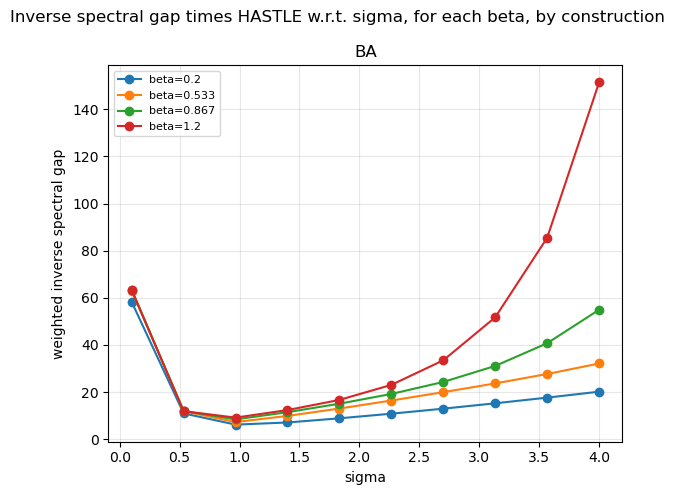

{'BA': beta       0.200000   0.533333   0.866667    1.200000
 sigma                                                
 0.100000  58.217344  63.078537  63.466245   63.233019
 0.533333  10.918021  11.831772  11.904073   11.858859
 0.966667   6.155984   7.244699   8.377126    9.125695
 1.400000   7.058651   9.848034  11.434612   12.330296
 1.833333   8.828594  12.990289  15.039653   16.643361
 2.266667  10.794429  16.386029  19.171353   23.020953
 2.700000  12.925285  19.929768  24.266210   33.448675
 3.133333  15.203715  23.642426  31.069732   51.697729
 3.566667  17.612541  27.638451  40.700803   85.457064
 4.000000  20.133810  32.103484  54.906119  151.420393}

In [12]:
plot_convergence_time_times_hastle(results_BA, 'BA',HASTLE_FUNCTIONS[hastle_name],'convergence_time' )
plot_convergence_time_times_hastle(results_BA, 'BA',HASTLE_FUNCTIONS[hastle_name],'inverse_gap' )

# Normalized weighted plots 

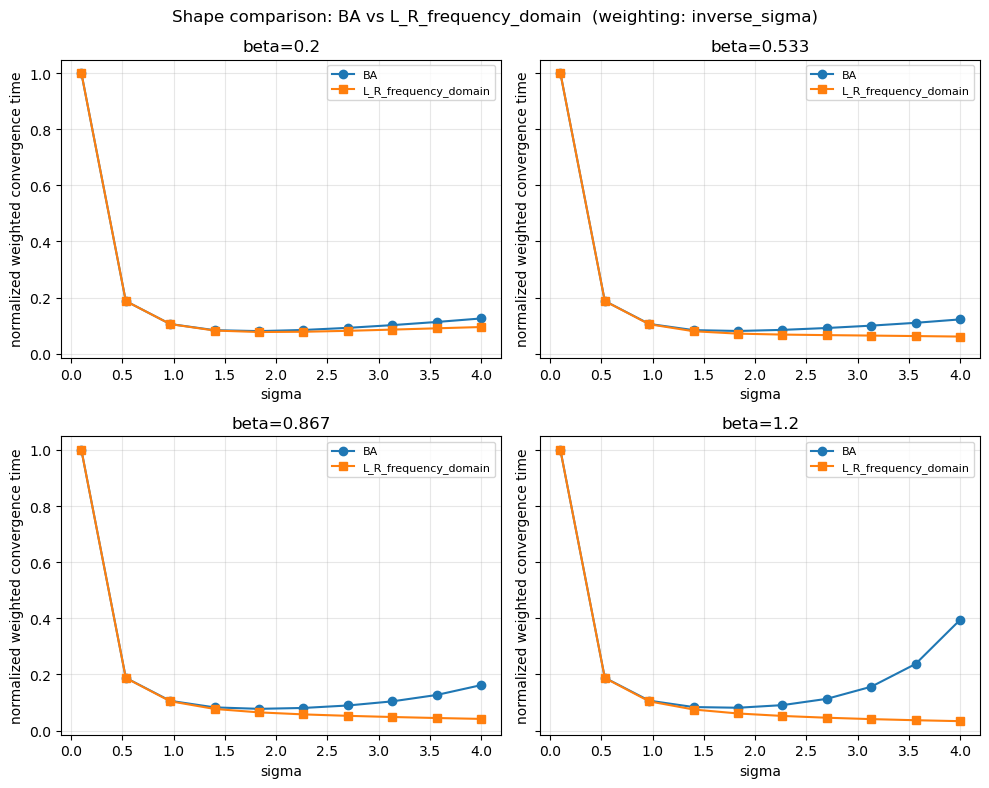

In [13]:
conv_time_times_hastle_L_BA = convergence_time_times_hastle(results_BA, ('BA',), HASTLE_FUNCTIONS[hastle_name])
conv_time_times_hastle_L_R_frequency_domain = convergence_time_times_hastle(results_df, ('L_R_frequency_domain',), HASTLE_FUNCTIONS[hastle_name])

plot_normalized_construction_comparison(
    weighted_by_construction_1=conv_time_times_hastle_L_BA,
    weighted_by_construction_2=conv_time_times_hastle_L_R_frequency_domain,
    construction_1="BA",
    construction_2="L_R_frequency_domain",
    normalize="max",
    hastle_name=hastle_name,
)


## Locate & refine the sigma minimum of the weighted SPECTRAL GAP

Same computation as the two cells above (`run_convergence_sweep` + `convergence_time_times_hastle`), but with a much denser sigma grid, followed by:
1. Finding the sigma that minimizes the weighted convergence time, per (construction, beta) -- if the argmin sits on the edge of the sigma grid, no interior minimum was found.
2. Zooming in: re-sweeping a finer sigma grid bracketing each coarse minimum to pin it down more precisely.

In [35]:
sigma_values_dense = np.linspace(0.1, 4, 30)  
beta_values_ = np.linspace(0.2, 1.7, 10)


minima_results = sweep_and_locate_sigma_minima(
    hamiltonian, sigma_values_dense, beta_values_, grid_with_beta_dependency, S_value, coupling_ops,
    constructions=("BA",),
    hastle_function=HASTLE_FUNCTIONS[hastle_name],
    n_sigma_fine=25,
    q_filter=q_filter_, threshold=threshold_value, max_time=max_evo_time, metric='inverse_gap', method=method_for_evo)


[1/300] BA                sigma=0.1 beta=0.2 -> t_conv=28.791  L+_res=9.31e-15  DB_res=1.14e-08  spectral_gap 0.171770
[2/300] BA                sigma=0.1 beta=0.3667 -> t_conv=32.7836  L+_res=7.45e-15  DB_res=3.17e-08  spectral_gap 0.162140
[3/300] BA                sigma=0.1 beta=0.5333 -> t_conv=34.6869  L+_res=7.55e-15  DB_res=5.09e-08  spectral_gap 0.158533
[4/300] BA                sigma=0.1 beta=0.7 -> t_conv=35.945  L+_res=3.04e-15  DB_res=6.25e-08  spectral_gap 0.157551
[5/300] BA                sigma=0.1 beta=0.8667 -> t_conv=36.6391  L+_res=4.22e-15  DB_res=6.49e-08  spectral_gap 0.157564
[6/300] BA                sigma=0.1 beta=1.033 -> t_conv=37.0369  L+_res=1.95e-15  DB_res=5.51e-08  spectral_gap 0.157854
[7/300] BA                sigma=0.1 beta=1.2 -> t_conv=37.2759  L+_res=4.22e-15  DB_res=2.97e-08  spectral_gap 0.158145
[8/300] BA                sigma=0.1 beta=1.367 -> t_conv=37.4217  L+_res=9.21e-15  DB_res=1.40e-08  spectral_gap 0.158363
[9/300] BA                sig

Refined minimum sigma:

In [36]:
minima_results["refined_minima_df"]

,construction,beta,coarse_min_sigma,coarse_min_value,refined_min_sigma,refined_min_value
0,BA,0.200000,1.041379,5.811722,1.041379,5.811722
1,BA,0.366667,1.041379,6.802966,0.974138,6.518714
2,BA,0.533333,0.906897,7.052212,0.918103,7.010351
3,BA,0.700000,0.906897,7.545448,0.873276,7.376168
4,BA,0.866667,0.906897,8.033383,0.839655,7.683319
5,BA,1.033333,0.772414,8.222390,0.806034,7.916731
6,BA,1.200000,0.772414,8.203896,0.783621,8.150478
7,BA,1.366667,0.772414,8.388804,0.761207,8.344616
8,BA,1.533333,0.772414,8.631925,0.738793,8.547203
9,BA,1.700000,0.772414,8.840039,0.727586,8.686463


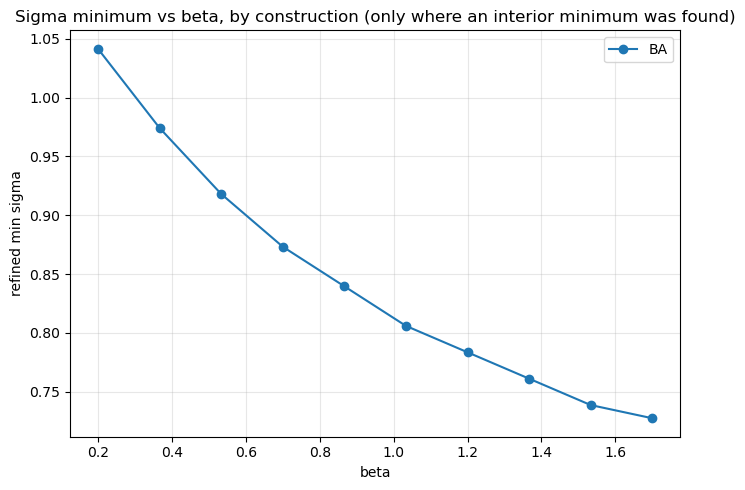

In [37]:
plot_sigma_minima_vs_beta(minima_results["refined_minima_df"], show_inverse_beta=False, fit_inverse_beta= False)


Denser version of the weighted-convergence-time plot (more sigma points per line): THIS IS THE SPECTRAL GAP TIMES HASTLE!!!

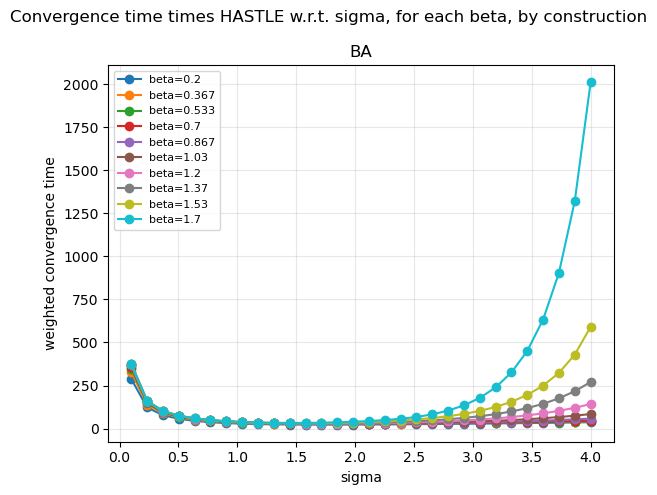

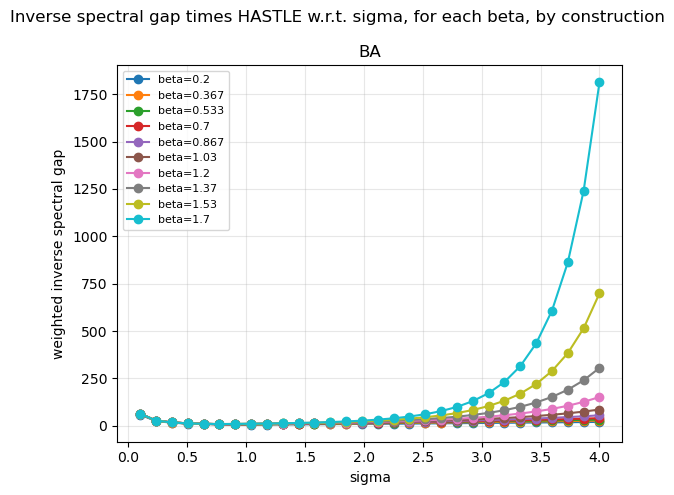

{'BA': beta       0.200000   0.366667   0.533333   0.700000   0.866667   1.033333  \
 sigma                                                                        
 0.100000  58.217344  61.675273  63.078537  63.471700  63.466245  63.349826   
 0.234483  24.829065  26.304466  26.903243  27.070899  27.068326  27.018323   
 0.368966  15.780252  16.718573  17.099446  17.206010  17.204156  17.172052   
 0.503448  11.565862  12.254145  12.533607  12.611750  12.610230  12.586421   
 0.637931   9.130204   9.674114   9.895006   9.956642   9.955129   9.935871   
 0.772414   7.560143   8.011372   8.194078   8.243900   8.240687   8.222390   
 0.906897   6.505997   6.896214   7.052212   7.545448   8.033383   8.437205   
 1.041379   5.811722   6.802966   7.633483   8.306624   8.842131   9.265904   
 1.175862   6.247739   7.427416   8.405230   9.172685   9.756345  10.199944   
 1.310345   6.723640   8.112868   9.251109  10.115120  10.744686  11.210250   
 1.444828   7.230778   8.847574  10.154919  11

In [38]:
plot_convergence_time_times_hastle(minima_results["coarse_results_df"], 'BA', HASTLE_FUNCTIONS[hastle_name], 'convergence_time' )
plot_convergence_time_times_hastle(minima_results["coarse_results_df"], 'BA', HASTLE_FUNCTIONS[hastle_name], 'inverse_gap' )

## Convergence-time sweep for time domain (separated since takes very long)

Runs the sweep across every construction, sigma, and beta combination and records the convergence time plus the two structural diagnostics (L^dagger(I) residual, detailed-balance residual).

In [18]:
results_df_time_domain = run_convergence_sweep(
    hamiltonian, sigma_values, beta_values, grid_with_sigma_and_beta_dependency, S_value, coupling_ops,
    constructions= ( "time_domain",),
    q_filter=q_filter_, threshold= threshold_value, max_time=max_evo_time, method=method_for_evo)

n_invalid = (~results_df_time_domain["valid_generator"]).sum()
print(f"{n_invalid} / {len(results_df_time_domain)} grid points have an invalid generator "
      f"(failed L^dagger(I)=0 or detailed balance), broken down by construction:")
print(results_df_time_domain.groupby("construction")["valid_generator"].agg(lambda s: (~s).sum()))

results_df_time_domain


KeyError: 'time_domain'

In [ ]:
plot_convergence_heatmap(results_df_time_domain)
plot_convergence_lines(results_df_time_domain)
plot_spectral_gap_lines(results_df_time_domain)